<a href="https://colab.research.google.com/github/ritikagulwani/Stock_Market_Analysis/blob/main/Stock_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q yfinance

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
import yfinance as yf

tech_list = ['AAPL','GOOG','MSFT','AMZN']

In [ ]:
from datetime import datetime

end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)

for stock in tech_list:
    globals()[stock] = yf.download(stock, start, end)

/tmp/ipykernel_4506/880547220.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4506/880547220.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4506/880547220.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4506/880547220.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed


In [ ]:
company_list = [AAPL, GOOG, MSFT, AMZN]
company_name = ["APPLE", "GOOGLE", "MICROSOFT", "AMAZON"]

for company, com_name in zip(company_list, company_name):
    company["company_name"] = com_name

df = pd.concat(company_list, axis=0)
df.head()

Price,Close,High,Low,Open,Volume,company_name,Close,High,Low,Open,...,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,GOOG,GOOG,GOOG,GOOG,...,MSFT,MSFT,MSFT,MSFT,MSFT,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-22,200.564316,201.948823,198.910872,199.916890,46742400.0,APPLE,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-23,194.498398,196.918788,192.695552,192.904714,78432900.0,APPLE,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-27,199.418869,199.946773,196.649840,197.516413,56288500.0,APPLE,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-28,199.628036,201.928906,199.110087,199.797363,45339700.0,APPLE,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-29,199.159882,203.004629,197.725569,202.775542,51396800.0,APPLE,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.tail()

Price,Close,High,Low,Open,Volume,company_name,Close,High,Low,Open,...,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,GOOG,GOOG,GOOG,GOOG,...,MSFT,MSFT,MSFT,MSFT,MSFT,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-18,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,264.859985,268.850006,262.529999,263.869995,33690800.0
2026-05-19,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,259.339996,262.250000,255.190002,262.040009,40340700.0
2026-05-20,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,265.010010,265.579987,259.529999,260.049988,34933200.0
2026-05-21,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,268.459991,269.489990,261.369995,263.500000,36510000.0
2026-05-22,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,268.609985,269.785004,268.059998,268.649994,3214977.0


In [ ]:
# Summary Stats
MSFT.describe()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
count,252.000000,252.000000,252.000000,252.000000,2.520000e+02
mean,464.366358,468.404105,460.259347,464.638144,2.652155e+07
std,47.576771,47.453271,47.895086,47.858305,1.285378e+07
min,355.998932,361.666679,355.510003,361.117850,3.781965e+06
25%,418.609116,422.662056,412.833351,418.654339,1.750110e+07
50%,478.578751,482.098062,473.750236,478.190075,2.405945e+07
75%,504.892410,508.149288,501.278326,505.138346,3.200822e+07
max,538.658508,551.048474,537.366702,550.830186,1.288553e+08


In [ ]:
MSFT.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2025-05-22 to 2026-05-22
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, MSFT)     252 non-null    float64
 1   (High, MSFT)      252 non-null    float64
 2   (Low, MSFT)       252 non-null    float64
 3   (Open, MSFT)      252 non-null    float64
 4   (Volume, MSFT)    252 non-null    int64  
 5   (company_name, )  252 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 13.8+ KB


**A stock’s closing price is the standard benchmark used by investors to track its performance over time. Histogram for closing price**

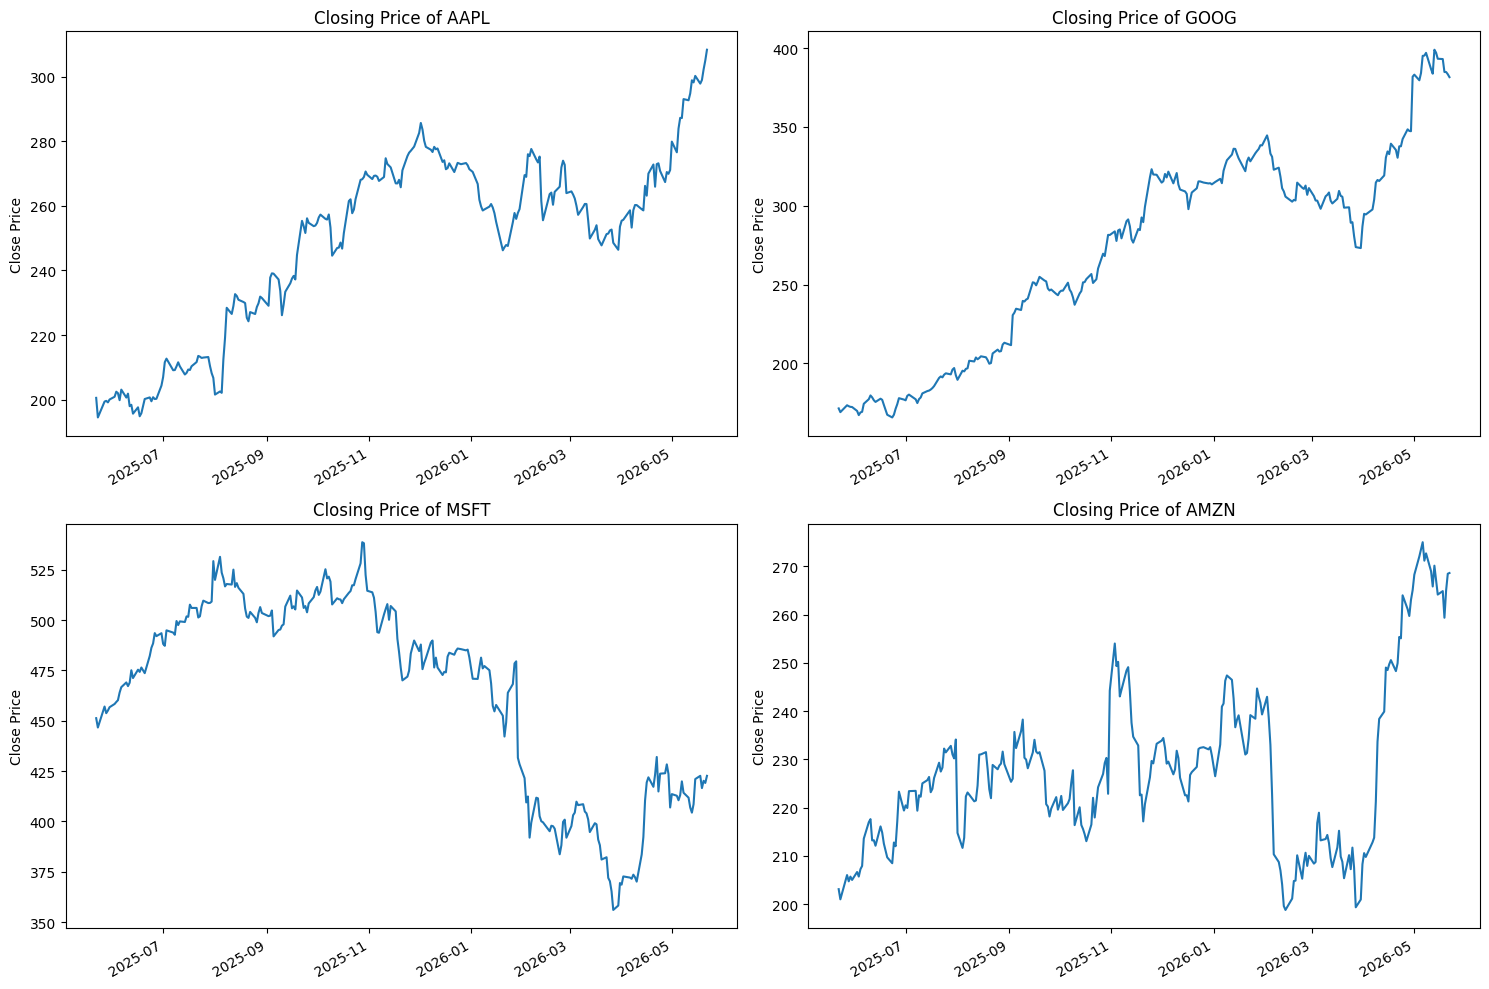

In [ ]:
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company[('Close', tech_list[i - 1])].plot()
    plt.ylabel('Close Price')
    plt.xlabel(None)
    plt.title(f"Closing Price of {tech_list[i - 1]}")

plt.tight_layout()

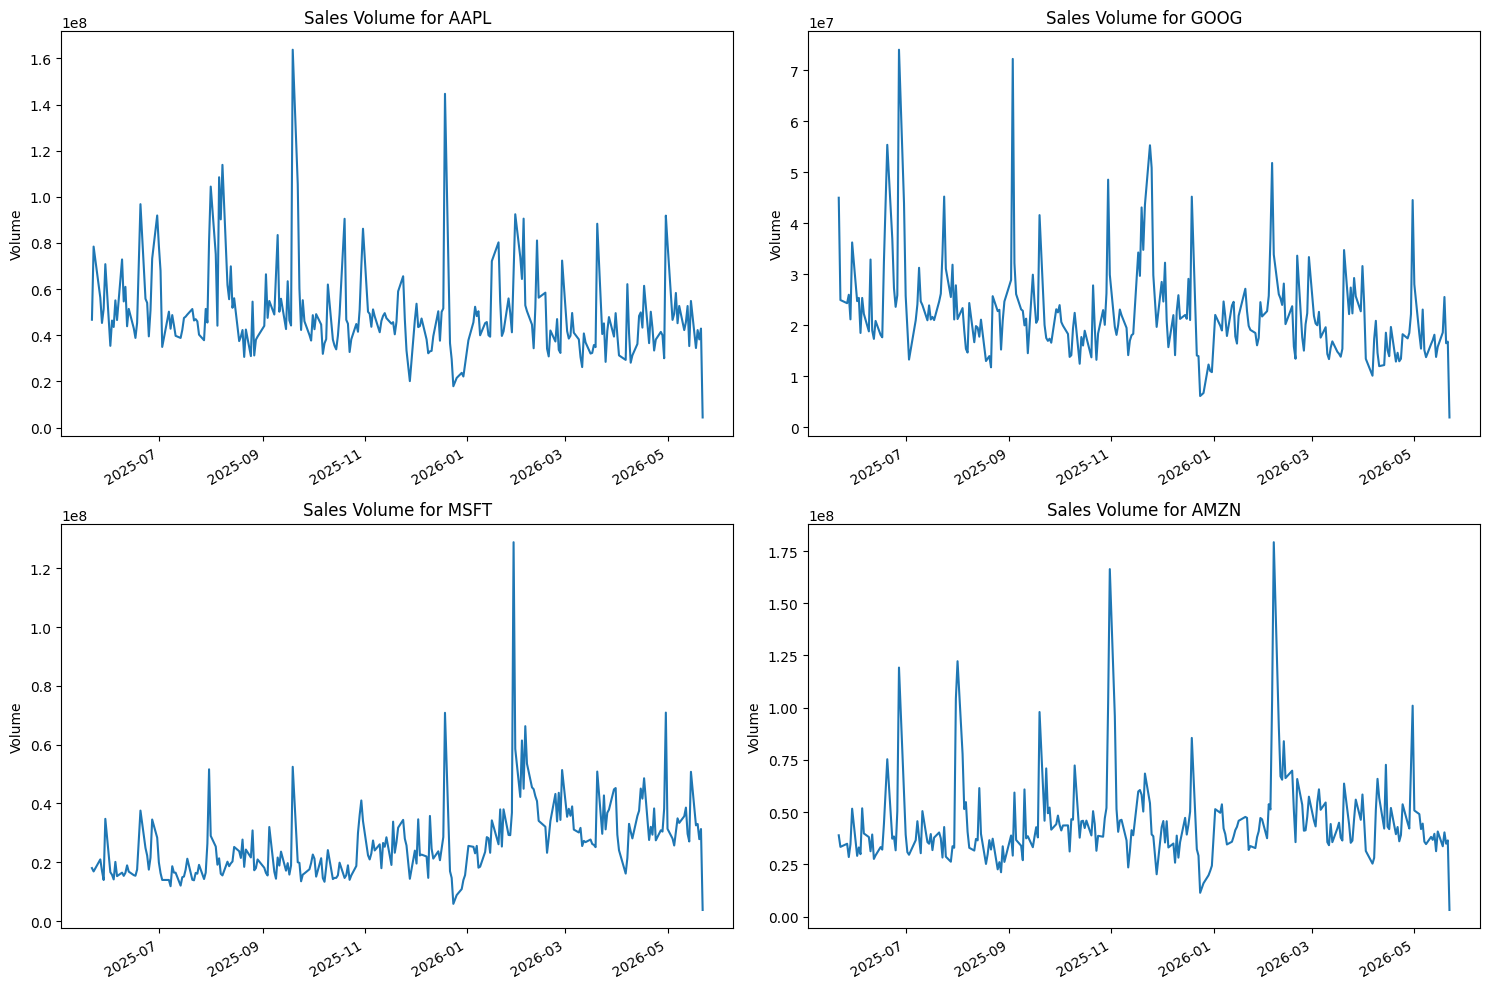

In [ ]:
# Now let's plot the total volume of stock being traded each day
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company[('Volume',tech_list[i - 1])].plot()
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f"Sales Volume for {tech_list[i - 1]}")

plt.tight_layout()

 creating a constantly updated average price. The average is taken over a specific period of time, like 10 days, 20 minutes, 30 weeks, or any time period the trader chooses.

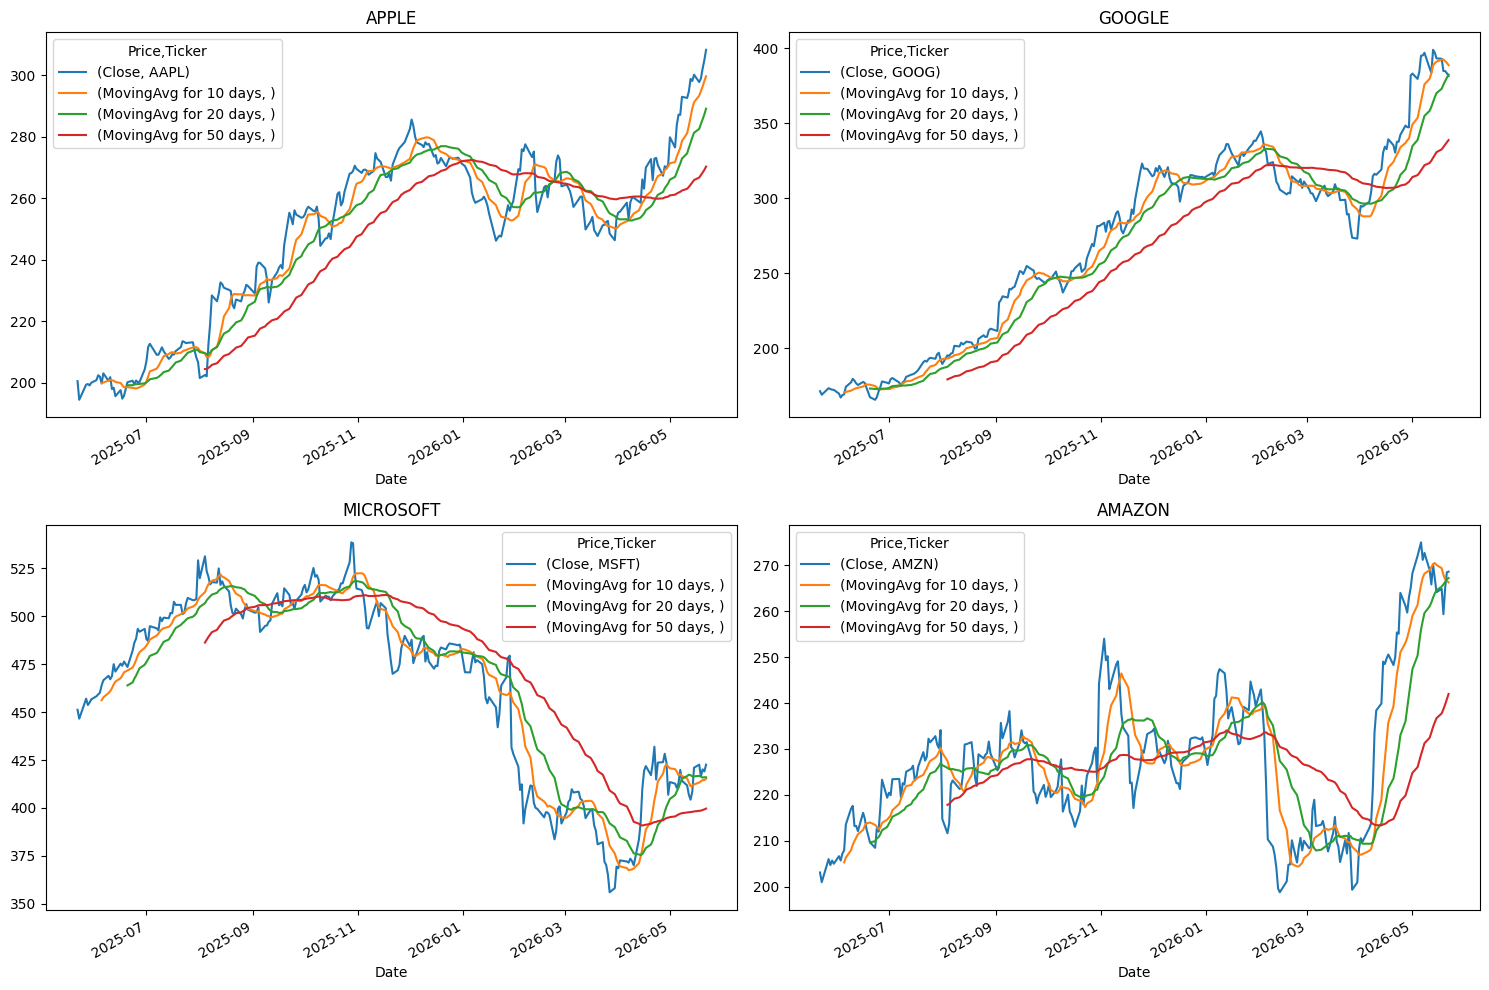

In [ ]:
A_day = [10, 20, 50]

for A in A_day:
    for company in company_list:
        column_name = f"MovingAvg for {A} days"
        company[column_name] = company[('Close', company.columns.get_level_values('Ticker')[0])].rolling(A).mean()


fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

AAPL[['Close', 'MovingAvg for 10 days', 'MovingAvg for 20 days', 'MovingAvg for 50 days']].plot(ax=axes[0,0])
axes[0,0].set_title('APPLE')

GOOG[['Close', 'MovingAvg for 10 days', 'MovingAvg for 20 days', 'MovingAvg for 50 days']].plot(ax=axes[0,1])
axes[0,1].set_title('GOOGLE')

MSFT[['Close', 'MovingAvg for 10 days', 'MovingAvg for 20 days', 'MovingAvg for 50 days']].plot(ax=axes[1,0])
axes[1,0].set_title('MICROSOFT')

AMZN[['Close', 'MovingAvg for 10 days', 'MovingAvg for 20 days', 'MovingAvg for 50 days']].plot(ax=axes[1,1])
axes[1,1].set_title('AMAZON')

fig.tight_layout()

We're now going to analyze the risk of the stock. In order to do so we'll need to take a closer look at the daily changes of the stock, and not just its absolute value. Let's go ahead and use pandas to retrieve the daily returns for stocks.

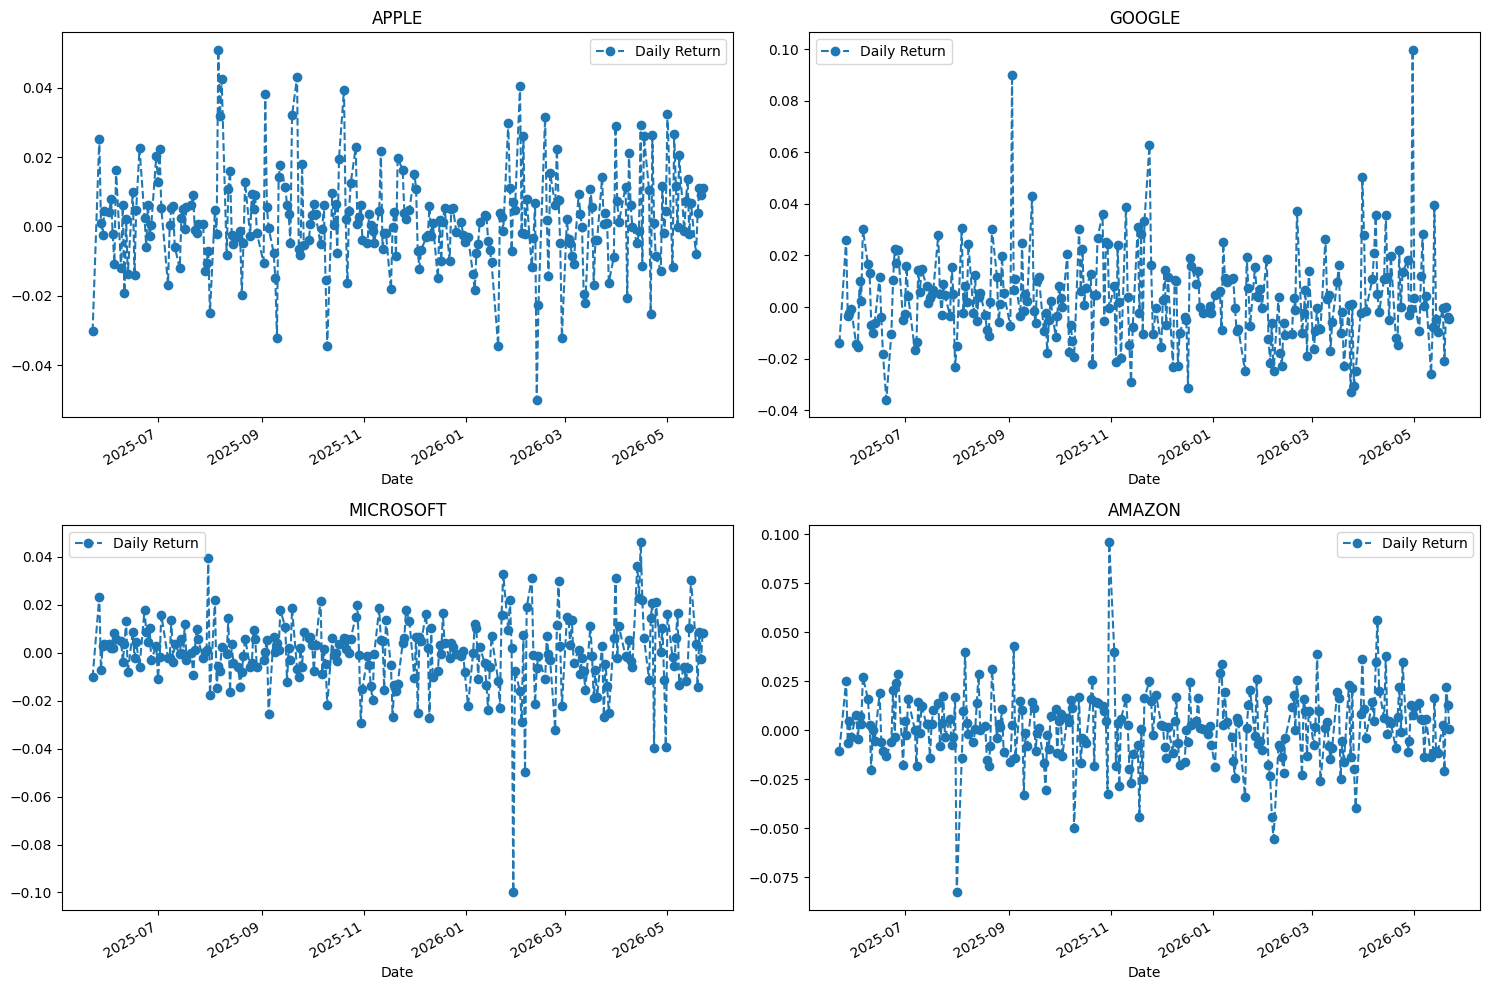

In [ ]:
# We'll use pct_change to find the percent change for each day
for company in company_list:
    company['Daily Return'] = company[('Close', company.columns.get_level_values('Ticker')[0])].pct_change()

# Then we'll plot the daily return percentage
fig, axes = plt.subplots(nrows=2, ncols=2);
fig.set_figheight(10)
fig.set_figwidth(15)

AAPL['Daily Return'].plot(ax=axes[0,0], legend=True, linestyle='--', marker='o')
axes[0,0].set_title('APPLE')

GOOG['Daily Return'].plot(ax=axes[0,1], legend=True, linestyle='--', marker='o')
axes[0,1].set_title('GOOGLE')

MSFT['Daily Return'].plot(ax=axes[1,0], legend=True, linestyle='--', marker='o')
axes[1,0].set_title('MICROSOFT')

AMZN['Daily Return'].plot(ax=axes[1,1], legend=True, linestyle='--', marker='o')
axes[1,1].set_title('AMAZON')

fig.tight_layout()

let's get an overall look at the average daily return using a histogram for better understading. We'll use seaborn to create both a histogram and kde plot on the same figure.

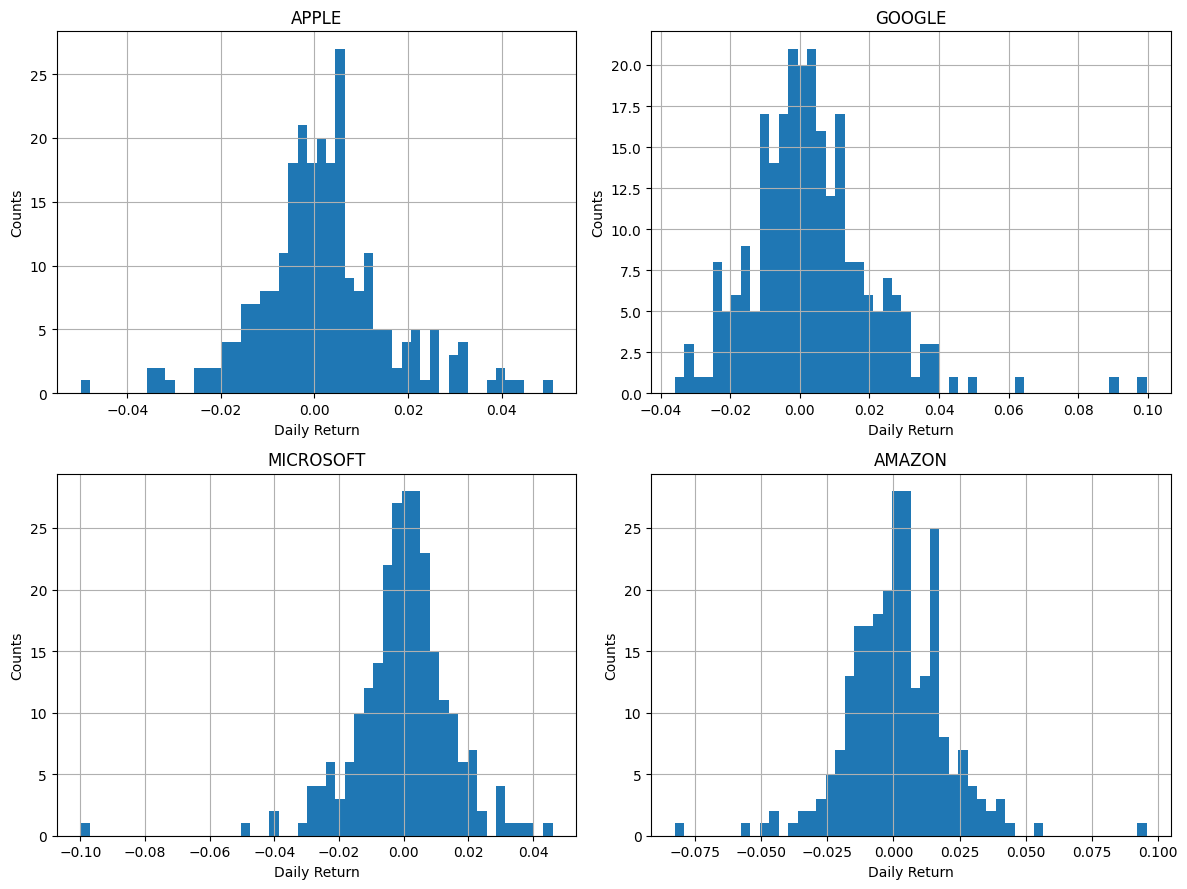

In [ ]:
plt.figure(figsize=(12, 9))

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Daily Return'].hist(bins=50)
    plt.xlabel('Daily Return')
    plt.ylabel('Counts')
    plt.title(f'{company_name[i - 1]}')

plt.tight_layout()

we wanted to analyze the returns of all the stocks in our list. Let's build a DataFrame with all the ['Close'] columns for each of the stocks dataframes.

In [ ]:
# Grab all the closing prices for the tech stock list into one DataFrame
closing_df = pd.DataFrame({
    'AAPL': AAPL[('Close', 'AAPL')],
    'GOOG': GOOG[('Close', 'GOOG')],
    'MSFT': MSFT[('Close', 'MSFT')],
    'AMZN': AMZN[('Close', 'AMZN')]
})


# Make a new tech returns DataFrame
tech_rets = closing_df.pct_change()
tech_rets.tail()

,AAPL,GOOG,MSFT,AMZN
Date,,,,
2026-05-18,-0.007961,-0.000534,0.003840,0.002726
2026-05-19,0.003794,-0.020885,-0.014450,-0.020841
2026-05-20,0.010971,0.000000,0.008720,0.021863
2026-05-21,0.009065,-0.003715,-0.002523,0.013018
2026-05-22,0.010952,-0.004798,0.008412,0.000559


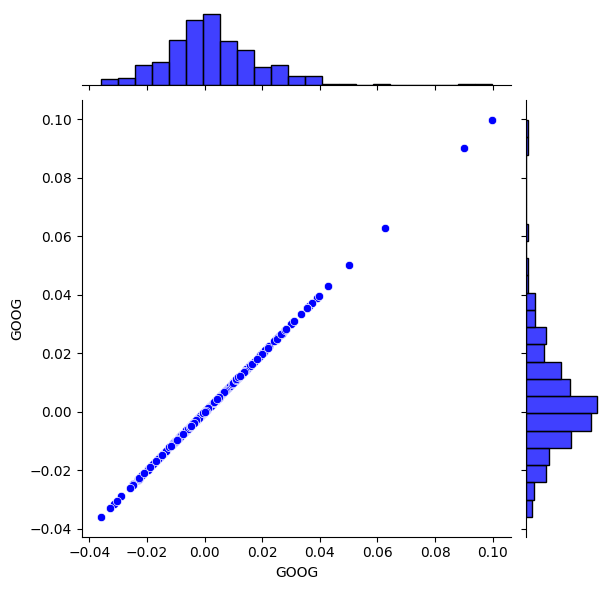

In [ ]:
# Comparing Google to itself should show a perfectly linear relationship
sns.jointplot(x='GOOG', y='GOOG', data=tech_rets, kind='scatter', color='blue')

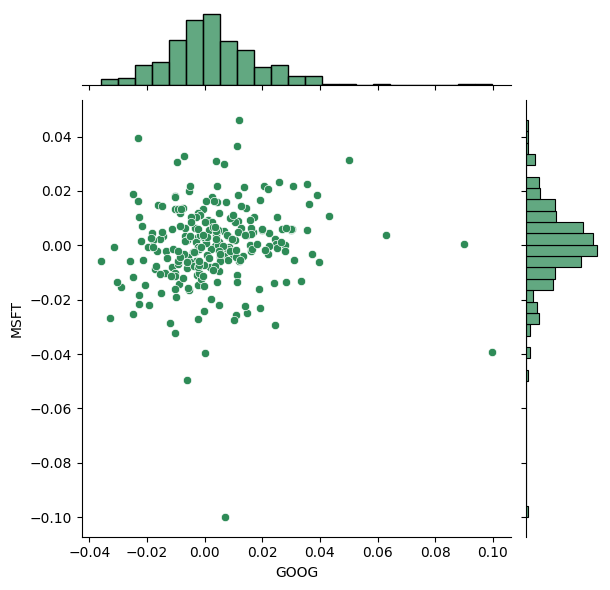

In [ ]:
# We'll use joinplot to compare the daily returns of Google and Microsoft
sns.jointplot(x='GOOG', y='MSFT', data=tech_rets, kind='scatter', color='seagreen')

Seaborn and pandas make it very easy to repeat this comparison analysis for every possible combination of stocks in our technology stock ticker list. We can use sns.pairplot() to automatically create this plot.

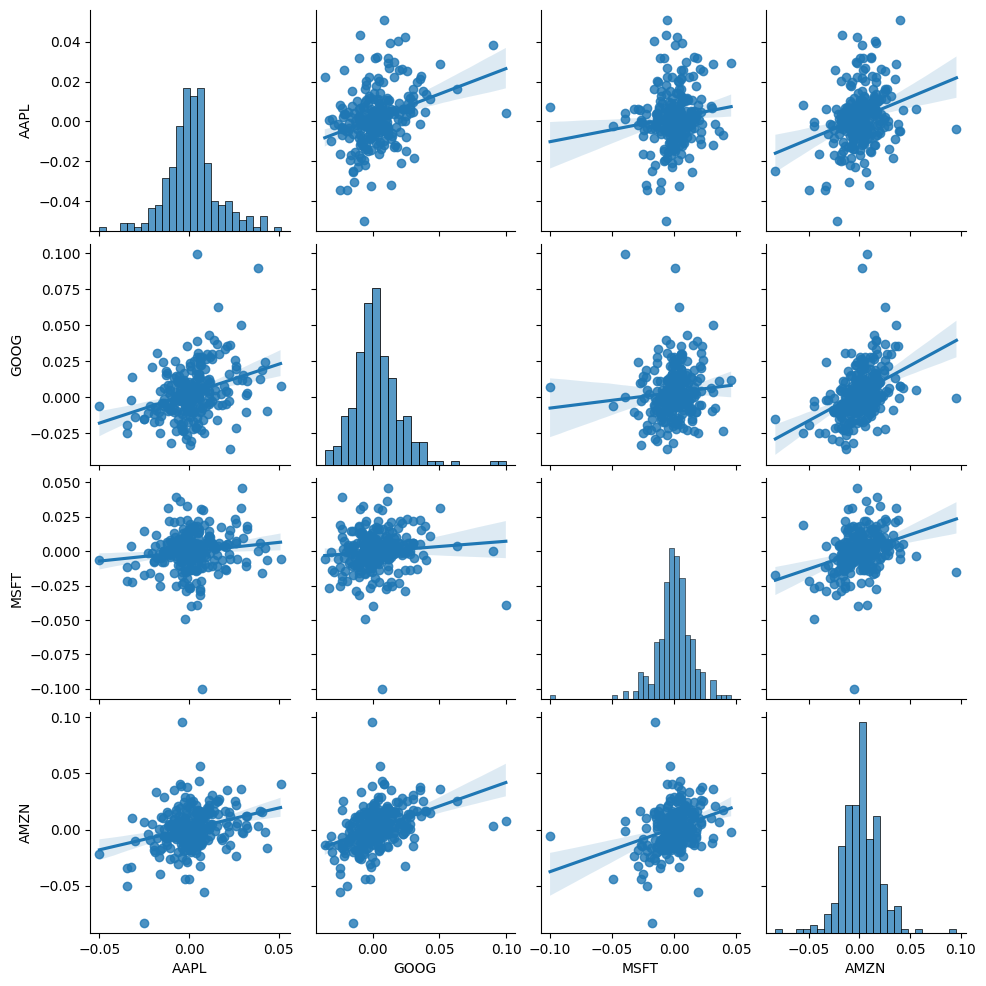

In [ ]:
sns.pairplot(tech_rets, kind='reg')

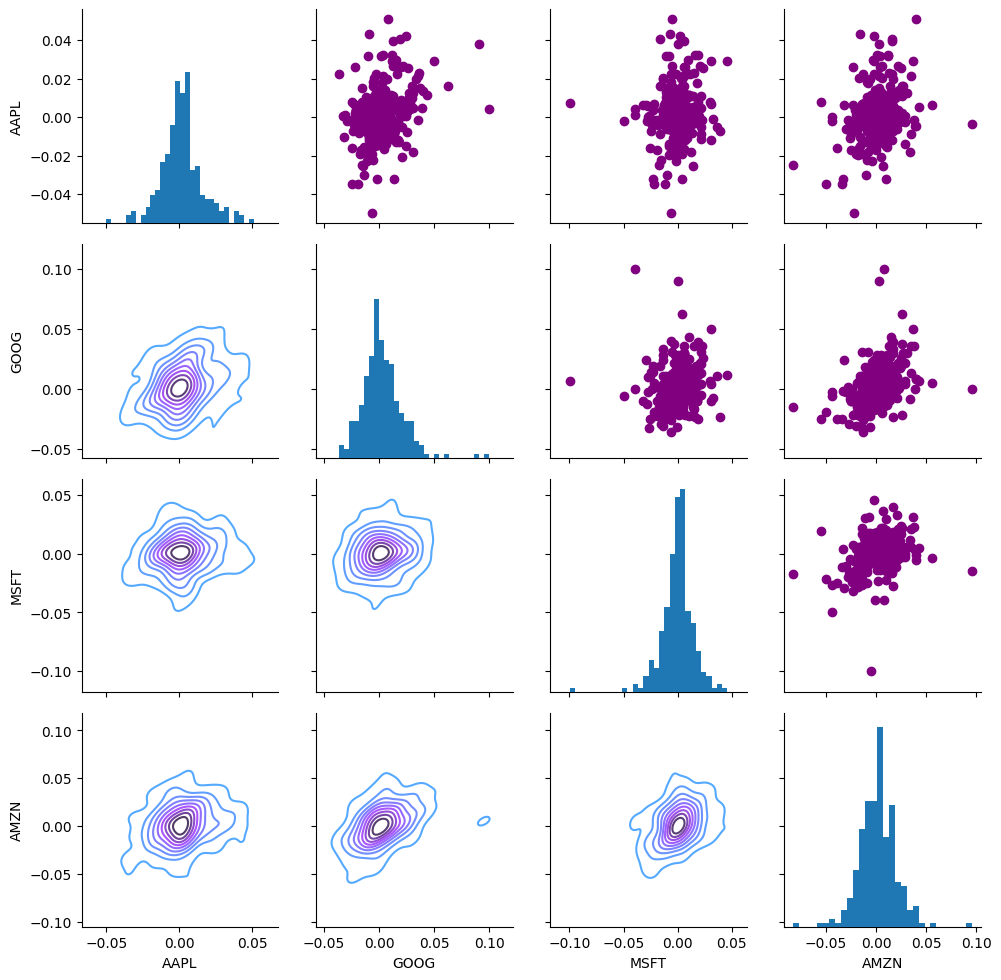

In [ ]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
return_fig = sns.PairGrid(tech_rets.dropna())

# Using map_upper we can specify what the upper triangle will look like.
return_fig.map_upper(plt.scatter, color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde) or the color map (BluePurple)
return_fig.map_lower(sns.kdeplot, cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
return_fig.map_diag(plt.hist, bins=30)

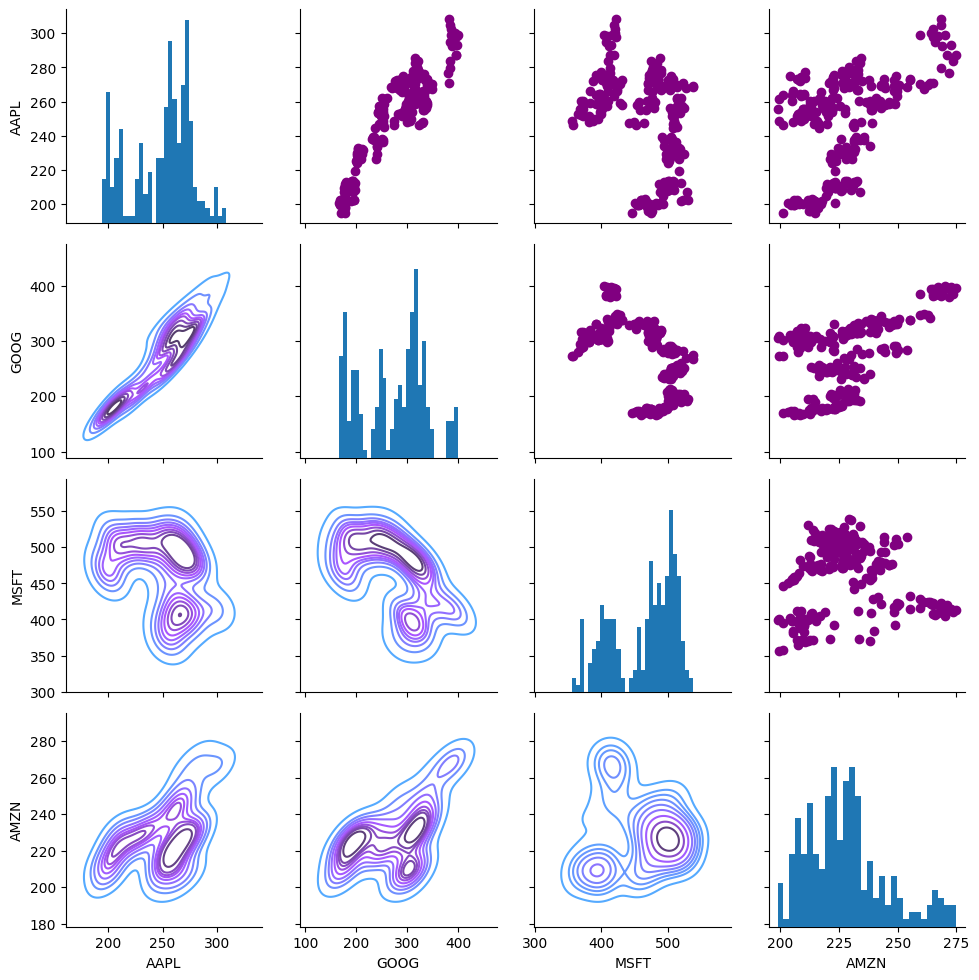

In [ ]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
returns_fig = sns.PairGrid(closing_df)

# Using map_upper we can specify what the upper triangle will look like.
returns_fig.map_upper(plt.scatter,color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde) or the color map (BluePurple)
returns_fig.map_lower(sns.kdeplot,cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
returns_fig.map_diag(plt.hist,bins=30)

we could also do a correlation plot, to get actual numerical values for the correlation between the stocks' daily return values.

Text(0.5, 1.0, 'Correlation of stock closing price')

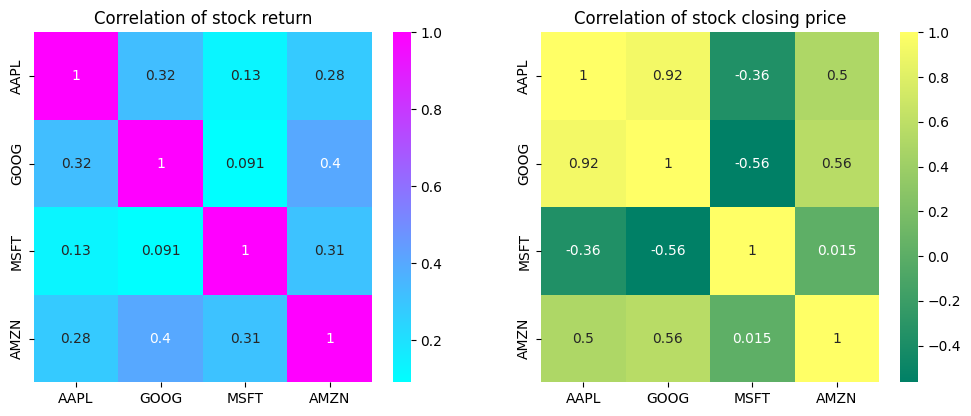

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(tech_rets.corr(), annot=True, cmap='cool')
plt.title('Correlation of stock return')

plt.subplot(2, 2, 2)
sns.heatmap(closing_df.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock closing price')

we see here numerically and visually that Microsoft and Amazon had the strongest correlation of daily stock return.

 The information we've gathered on daily percentage returns is by comparing the expected return with the standard deviation of the daily returns will help us to rectify the loss.

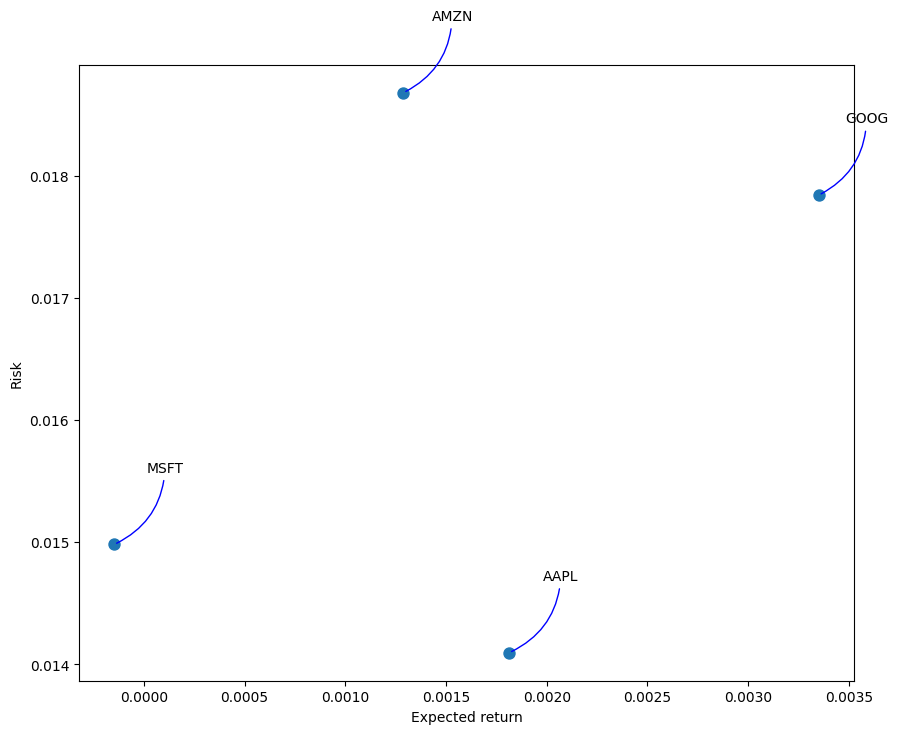

In [ ]:
# Grab all the closing prices for the tech stock list into one DataFrame
closing_df = pd.DataFrame({
    'AAPL': AAPL[('Close', 'AAPL')],
    'GOOG': GOOG[('Close', 'GOOG')],
    'MSFT': MSFT[('Close', 'MSFT')],
    'AMZN': AMZN[('Close', 'AMZN')]
})


# Make a new tech returns DataFrame
tech_rets = closing_df.pct_change()

rets = tech_rets.dropna()

area = np.pi * 20

plt.figure(figsize=(10, 8))
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected return')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(label, xy=(x, y), xytext=(50, 50), textcoords='offset points', ha='right', va='bottom',
                 arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))

# Predicting the closing price stock price of APPLE inc


In [ ]:
df = yf.download('AAPL', start='2014-01-01', end=datetime.now())

# Show the data
print(df)

/tmp/ipykernel_4506/2692214092.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2014-01-01', end=datetime.now())
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2014-01-02   17.124884   17.245628   17.090519   17.203832  234684800
2014-01-03   16.748724   17.142534   16.731695   17.116529  392467600
2014-01-06   16.840054   16.928908   16.520237   16.639433  412610800
2014-01-07   16.719618   16.902900   16.653983   16.852126  317209200
2014-01-08   16.825504   16.890519   16.677826   16.681539  258529600
...                ...         ...         ...         ...        ...
2026-05-18  297.839996  300.660004  294.910004  300.239990   34483000
2026-05-19  298.970001  300.510010  296.350006  296.970001   42243600
2026-05-20  302.250000  302.799988  298.079987  298.179993   38229800
2026-05-21  304.989990  305.540009  300.399994  301.059998   42900600
2026-05-22  308.204987  308.950012  305.850006  306.059998    4454062

[3116 rows x 5 colu

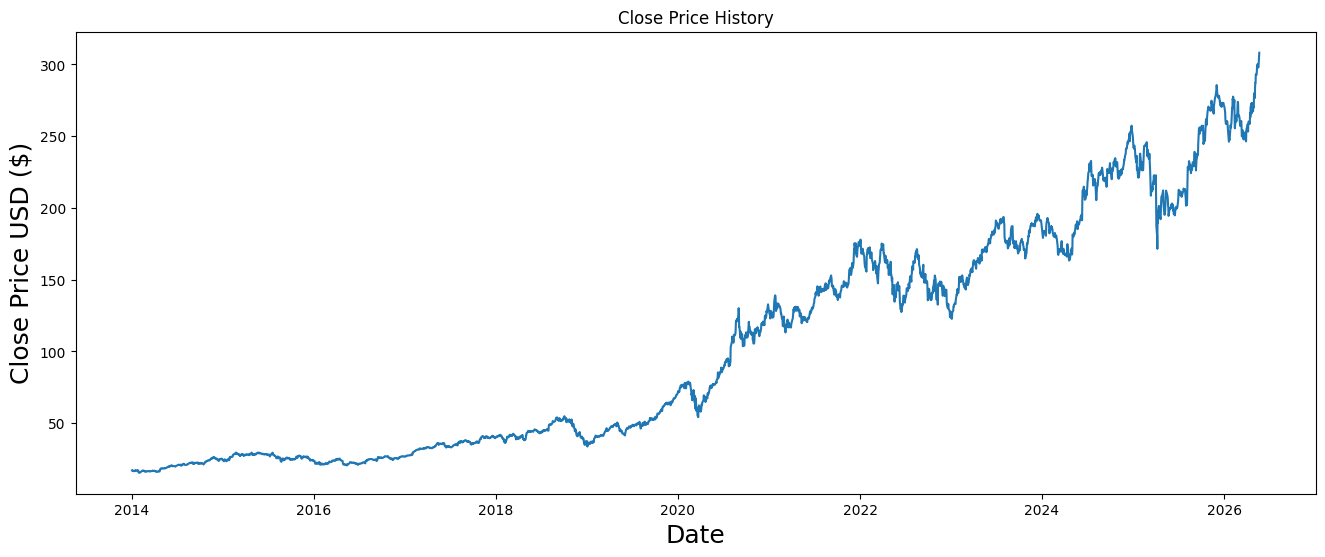

In [ ]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [ ]:
# Create a new dataframe with only the 'Close column
data = df.filter(['Close'])
# Convert the dataframe to a numpy array
dataset = data.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

2961

In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# Select the 'Close' column and reshape it into 2D
dataset = df[['Close']].values  # shape will be (2637, 1)

# Initialize and fit the scaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# Show the result
print(scaled_data)

[[0.00564242]
 [0.00435742]
 [0.00466941]
 ...
 [0.97965719]
 [0.98901726]
 [1.        ]]


In [ ]:
# Create the training data set
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_train.shape

[array([5.64241799e-03, 4.35742045e-03, 4.66941105e-03, 4.25799108e-03,
       4.61970939e-03, 3.88572387e-03, 3.50708432e-03, 3.80215368e-03,
       4.92959542e-03, 6.08979152e-03, 5.76088620e-03, 4.32462049e-03,
       5.21303428e-03, 5.47106197e-03, 5.96500961e-03, 4.89572689e-03,
       5.36427639e-03, 7.10734295e-04, 1.02628571e-04, 0.00000000e+00,
       8.67465866e-05, 1.85081321e-04, 9.52915831e-04, 1.35481964e-03,
       1.67083041e-03, 2.43369020e-03, 3.42419176e-03, 4.16581367e-03,
       4.16154589e-03, 5.06693957e-03, 5.02014391e-03, 5.23290712e-03,
       4.31581128e-03, 3.65400001e-03, 3.02629836e-03, 3.27102101e-03,
       2.68688976e-03, 2.18575531e-03, 3.28379828e-03, 3.13162443e-03,
       3.29334376e-03, 3.66360413e-03, 3.78278255e-03, 3.61145258e-03,
       3.57850276e-03, 3.62957922e-03, 4.17962692e-03, 4.23495161e-03,
       3.60083853e-03, 2.96672544e-03, 3.18481849e-03, 3.68062310e-03,
       3.66572173e-03, 3.39336605e-03, 3.83703215e-03, 4.50945095e-03,
     

(2901, 60, 1)

In [ ]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2901/2901 ━━━━━━━━━━━━━━━━━━━━ 130s 43ms/step - loss: 7.7640e-04


In [ ]:
# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step


np.float64(10.62028499096828)

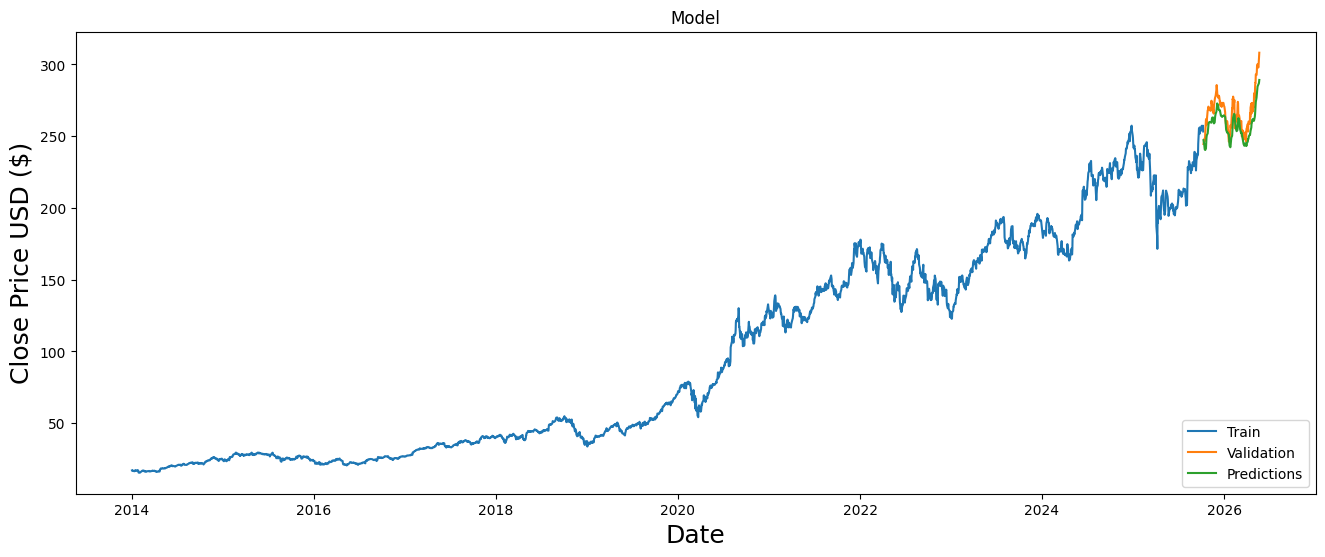

In [ ]:
valid = df[training_data_len:].copy()
look_back = len(valid) - len(predictions)
valid = valid.iloc[look_back:].copy()

# Add predictions column
valid['Predictions'] = predictions

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)

# Plot training data
plt.plot(df[:training_data_len]['Close'], label='Train')

# Plot validation and predictions
plt.plot(valid['Close'], label='Validation')
plt.plot(valid['Predictions'], label='Predictions')

plt.legend(loc='lower right')
plt.show()

In [ ]:
# Show the valid and predicted prices
valid

Price,Close,High,Low,Open,Volume,Predictions
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2025-10-10,244.578064,255.656722,243.311643,254.220782,61999100,247.255203
2025-10-13,246.961334,248.985606,244.867252,248.676483,38142900,244.389252
2025-10-14,247.071014,248.147969,244.009668,245.904317,35478000,242.247314
2025-10-15,248.636581,251.109596,246.771862,248.786167,33893600,240.930679
2025-10-16,246.751923,248.337433,244.438475,247.549669,39777000,240.672195
...,...,...,...,...,...,...
2026-05-18,297.839996,300.660004,294.910004,300.239990,34483000,286.025574
2026-05-19,298.970001,300.510010,296.350006,296.970001,42243600,286.358368


In [ ]:
# Assuming 'valid' dataframe and 'Date' column with index 0 is the date
# Assuming 'Predictions' column with index 6 is the prediction
# Assuming 'Close' column with index 1 is the actual close price

# Calculate the difference between the prediction and the closing price
valid['Difference'] = valid['Predictions'] - valid[('Close', 'AAPL')]

# Define strategy: Buy if prediction is higher than closing price, Sell if lower
valid['Signal'] = ['Buy' if diff > 0 else 'Sell' for diff in valid['Difference']]

# Display the rows where the signal is 'Buy'
print("Buy Signals:")
print(valid[valid['Signal'] == 'Buy'])

# Display the rows where the signal is 'Sell'
print("\nSell Signals:")
print(valid[valid['Signal'] == 'Sell'])

Buy Signals:
Price            Close        High         Low        Open    Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2025-10-10  244.578064  255.656722  243.311643  254.220782  61999100   
2026-01-06  261.873444  267.053821  261.633898  266.504853  52352100   
2026-01-20  246.242508  254.317502  242.968592  252.261324  80267500   
2026-01-21  247.190750  251.093503  244.725329  248.238806  54641700   
2026-02-12  261.489105  275.466219  259.940514  275.336333  81077200   
2026-02-13  255.544556  261.988631  255.214858  261.768832  56290700   
2026-03-13  249.889771  256.094046  249.290332  255.244837  36930000   

Price      Predictions Difference Signal  
Ticker                                    
Date                                      
2025-10-10  247.255203   2.677139    Buy  
2026-01-06  262.066376   0.192932    Buy  
2026-01-20  251.118912   4.876404    Buy  
2026-01-

In [ ]:
# Create a new array containing scaled values from index 1543 to 2002
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

predicted_price = predictions[-1][0]
current_price = y_test[-1][0]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


/tmp/ipykernel_4506/174455853.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if signals[i] == 'Buy':
/tmp/ipykernel_4506/174455853.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif signals[i] == 'Sell':


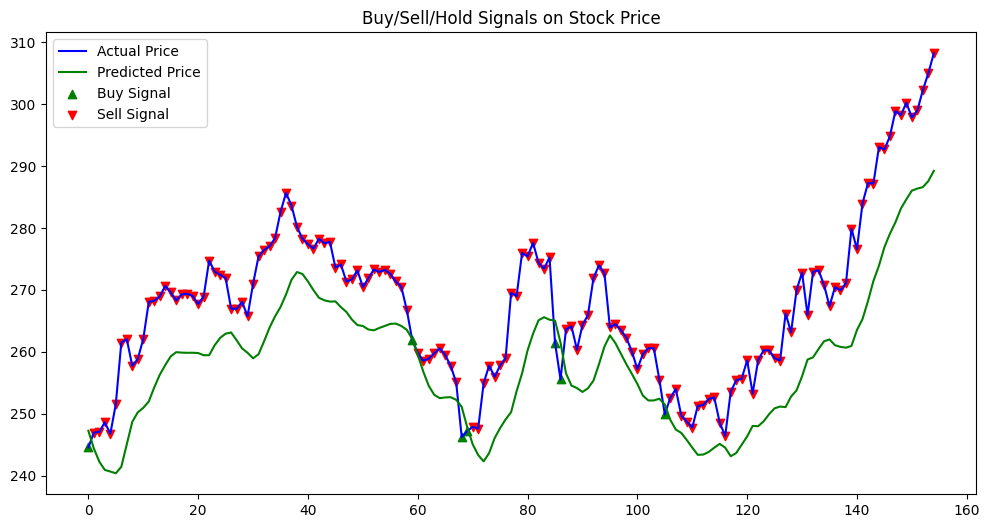

In [ ]:
buy_signals = []
sell_signals = []

signals = valid['Signal']
real_prices = y_test

for i in range(len(signals)):
    if signals[i] == 'Buy':
        buy_signals.append(real_prices[i][0])
        sell_signals.append(None)
    elif signals[i] == 'Sell':
        sell_signals.append(real_prices[i][0])
        buy_signals.append(None)
    else:
        buy_signals.append(None)
        sell_signals.append(None)

plt.figure(figsize=(12, 6))
plt.plot(real_prices, label='Actual Price', color='blue')
plt.plot(predictions, label='Predicted Price', color='green')
plt.scatter(range(len(buy_signals)), buy_signals, marker='^', color='green', label='Buy Signal')
plt.scatter(range(len(sell_signals)), sell_signals, marker='v', color='red', label='Sell Signal')
plt.title("Buy/Sell/Hold Signals on Stock Price")
plt.legend()
plt.show()

To make it more Accurate

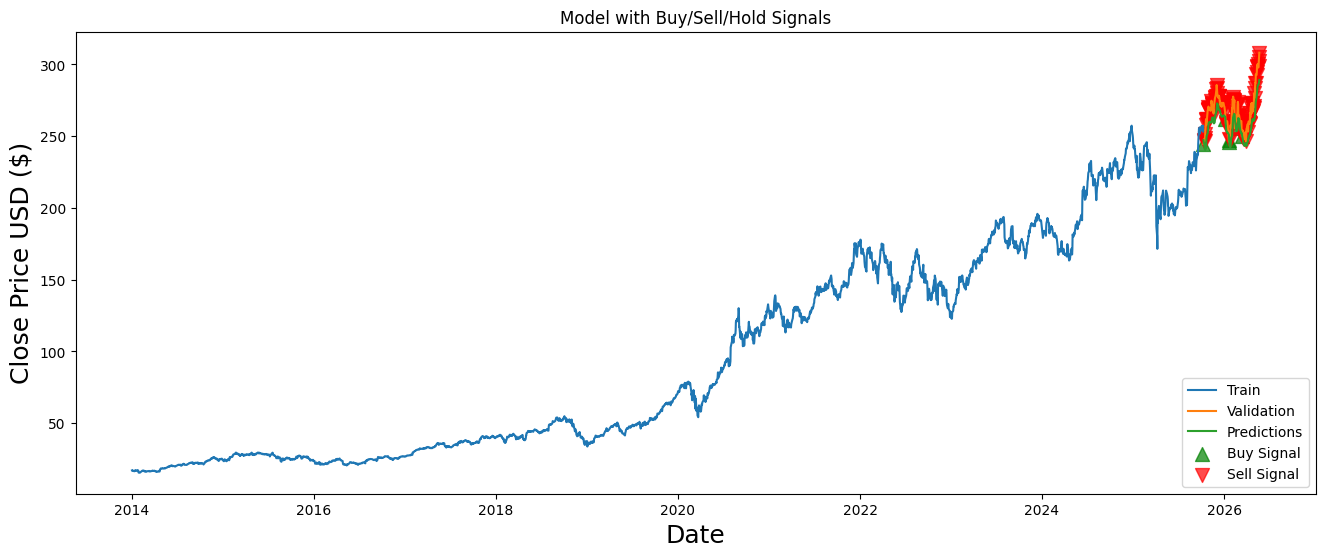


Valid DataFrame with Signals:
Price            Close Predictions Difference Signal
Ticker            AAPL                              
Date                                                
2026-05-18  297.839996  286.025574 -11.814423   Sell
2026-05-19  298.970001  286.358368 -12.611633   Sell
2026-05-20  302.250000  286.595001 -15.654999   Sell
2026-05-21  304.989990  287.577148 -17.412842   Sell
2026-05-22  308.204987  289.220215 -18.984772   Sell


In [ ]:
# Re-calculating the buy and sell signals based on whether the predicted price is higher or lower than the actual closing price
valid['Difference'] = valid['Predictions'] - valid[('Close', 'AAPL')]
valid['Signal'] = ['Buy' if diff > 0 else 'Sell' if diff < 0 else 'Hold' for diff in valid['Difference']]

buy_signals = []
sell_signals = []
hold_signals = []

# Assuming the 'Date' column is the index of the 'valid' DataFrame
dates = valid.index

for i in range(len(valid)):
    if valid['Signal'].iloc[i] == 'Buy':
        buy_signals.append((dates[i], valid[('Close', 'AAPL')].iloc[i]))
    elif valid['Signal'].iloc[i] == 'Sell':
        sell_signals.append((dates[i], valid[('Close', 'AAPL')].iloc[i]))
    else:
        hold_signals.append((dates[i], valid[('Close', 'AAPL')].iloc[i]))

# Plot
plt.figure(figsize=(16,6))
plt.title('Model with Buy/Sell/Hold Signals')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)

# Plot training data
plt.plot(df[:training_data_len]['Close'], label='Train')

# Plot validation and predictions
plt.plot(valid['Close'], label='Validation')
plt.plot(valid['Predictions'], label='Predictions')

# Plot Buy/Sell/Hold signals
buy_dates, buy_prices = zip(*buy_signals) if buy_signals else ([], [])
sell_dates, sell_prices = zip(*sell_signals) if sell_signals else ([], [])
hold_dates, hold_prices = zip(*hold_signals) if hold_signals else ([], [])

plt.scatter(buy_dates, buy_prices, marker='^', color='green', label='Buy Signal', s=100, alpha=0.7)
plt.scatter(sell_dates, sell_prices, marker='v', color='red', label='Sell Signal', s=100, alpha=0.7)
# You can optionally plot hold signals if you want
# plt.scatter(hold_dates, hold_prices, marker='o', color='orange', label='Hold Signal', s=50, alpha=0.5)


plt.legend(loc='lower right')
plt.show()

# Show the valid dataframe with signals
print("\nValid DataFrame with Signals:")
print(valid[['Close', 'Predictions', 'Difference', 'Signal']].tail())

In [ ]:
# Assumed initial cash is: 100000

initial_cash = 100000
cash = initial_cash
stock_holding = 0
portfolio_value = []
positions = []

for i in range(len(signals)):
    price = real_prices[i][0]
    signal = signals[i]

    if signal == "Buy" and stock_holding == 0:
        stock_holding = 1
        cash -= price
        positions.append(f"BUY @ ₹{price:.2f}")

    elif signal == "Sell" and stock_holding == 1:
        stock_holding = 0
        cash += price
        positions.append(f"SELL @ ₹{price:.2f}")

    else:
        positions.append("HOLD")

    total_value = cash + (stock_holding * price)
    portfolio_value.append(total_value)

/tmp/ipykernel_4506/1364162852.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  signal = signals[i]


Plot Portfolio Growth

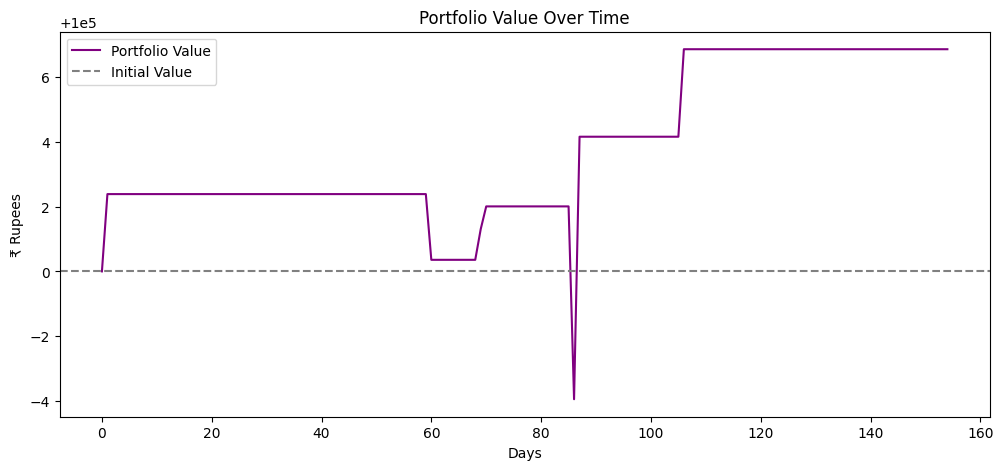

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(portfolio_value, label="Portfolio Value", color='purple')
plt.axhline(y=initial_cash, color='gray', linestyle='--', label="Initial Value")
plt.title("Portfolio Value Over Time")
plt.xlabel("Days")
plt.ylabel("₹ Rupees")
plt.legend()
plt.show()

In [ ]:
final_value = portfolio_value[-1]
profit = final_value - initial_cash
returns_pct = (profit / initial_cash) * 100

print(f"Initial Value: ₹{initial_cash:.2f}")
print(f"Final Value: ₹{final_value:.2f}")
print(f"Net Profit: ₹{profit:.2f} ({returns_pct:.2f}%)")
print(f"Total Trades: {positions.count('BUY')} buys, {positions.count('SELL')} sells")

Initial Value: ₹100000.00
Final Value: ₹100006.85
Net Profit: ₹6.85 (0.01%)
Total Trades: 0 buys, 0 sells
